# NeMo Nepali ASR Fine-Tuning on Colab T4

This notebook fine-tunes `indicconformer_stt_ne_hybrid_ctc_rnnt_large_v2.nemo` with split-specific manifests:

- `dataset/train/manifest.jsonl`
- `dataset/validation/manifest.jsonl`
- `dataset/test/manifest.jsonl`

It keeps the original dependency installation block unchanged, normalizes split manifests without resampling audio, supports checkpoint resume, exports `.nemo` artifacts for future continued fine-tuning, logs epoch metrics, and saves research-ready plots.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/asrdataset/asrdataset.zip /content/
!unzip -q /content/asrdataset.zip -d /content/

In [ ]:
# sangam appraoch
# Pin huggingface_hub to avoid ModelFilter import error in AI4Bharat NeMo fork
!pip install -q "huggingface_hub==0.15.1"
print("✅ huggingface_hub pinned")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 21.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.15.1 which is incompatible.
gradio-client 1.14.0 requires huggingface-hub<2.0,>=0.19.3, but you have huggingface-hub 0.15.1 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.15.1 which is incompatible.
sentence-transformers 5.3.0 requires huggingface-hub>=0.20.0, but you have huggingface-hub 0.15.1 which is incompatible.
accelerate 1.13.0 requires huggingface_hub>=0.21.0, but you have huggingface-hub 0.15.1 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.15.1 which is incompatible.
peft 0.18.1 requires huggingface_hub>=0.25.0, but you 

In [ ]:
# Core ML + audio dependencies
!pip install -q \
    torch==2.1.0 \
    torchaudio==2.1.0 \
    pytorch-lightning==2.0.9 \
    omegaconf \
    hydra-core \
    scipy soundfile librosa sentencepiece editdistance jiwer packaging Cython
print("✅ Core dependencies installed")

ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==2.1.0
✅ Core dependencies installed


In [ ]:
# Clone and install AI4Bharat NeMo fork
import os
if not os.path.exists("/content/NeMo"):
    !git clone -q https://github.com/AI4Bharat/NeMo.git /content/NeMo
    print("✅ Cloned AI4Bharat NeMo")
else:
    print("ℹ️  NeMo already cloned")

%cd /content/NeMo
!git checkout -q nemo-v2
!pip install -q -e ".[asr]"
print("✅ AI4Bharat NeMo installed")

✅ Cloned AI4Bharat NeMo
/content/NeMo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta

In [ ]:
# Verify installation
import nemo
import nemo.collections.asr as nemo_asr
import torch
print(f"✅ NeMo  : {nemo.__version__}")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

[NeMo W 2026-03-20 08:09:11 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
      m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
    
[NeMo W 2026-03-20 08:09:11 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
      m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
    
[NeMo W 2026-03-20 08:09:11 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
      elif re.match('(flt)p?( \(default\))?$', token):
    
[NeMo W 2026-03-20 08:09:11 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
      elif re.match('(dbl)p?( \(default\))?$', token):
    
[NeMo W 2026-03-20 08:09:17 nemo_logging:393] /content/NeMo/nemo/collections/asr/modules/audio_modules.py:1440: SyntaxWarning: inva

✅ NeMo  : 1.23.0rc0
✅ PyTorch: 2.10.0+cu128
✅ CUDA   : True
   GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Patch np.sctypes for NumPy >= 2.0 compatibility
import numpy as np
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'float': [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others': [bool, object, bytes, str]
    }
    print("✅ np.sctypes patched for NumPy 2.x")

✅ np.sctypes patched for NumPy 2.x


## Run Configuration

This notebook now keeps Colab's default NumPy instead of force-reinstalling an older one.

That avoids the restart loop you hit earlier, while the import cell below patches the NeMo `np.sctypes` issue for NumPy 2.x runtimes.

On a fresh Colab runtime, you can usually run the install cell once and continue directly.
If Colab still asks for a restart because some other preloaded package changed, restart once and then continue from the next cell below the install block.

Update the paths in the next cell to match your Google Drive layout.

- Set `model_init_path` to the base `.nemo` model or to a previously fine-tuned `.nemo` file for continued fine-tuning.
- Set `resume_checkpoint_path` only when you want to resume an interrupted Lightning run from `last.ckpt` or another `.ckpt`.
- If Colab runs out of memory, reduce `train_batch_size` from `4 -> 2 -> 1` before changing the rest of the pipeline.


In [ ]:
import gc
import json
import os
import random
import types
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import soundfile as sf
import torch
from IPython.display import display
from jiwer import cer, wer
from omegaconf import OmegaConf, open_dict
from numba.core.errors import NumbaPerformanceWarning
from pytorch_lightning import seed_everything
from pytorch_lightning.callbacks import Callback, EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

os.environ.setdefault("NUMBA_CUDA_USE_NVIDIA_BINDING", "1")


def patch_text_file(path: Path, replacements: Dict[str, str]) -> bool:
    if not path.exists():
        return False
    original_text = path.read_text()
    updated_text = original_text
    for old_text, new_text in replacements.items():
        updated_text = updated_text.replace(old_text, new_text)
    if updated_text == original_text:
        return False
    path.write_text(updated_text)
    return True


patched_nemo_files: List[str] = []
nemo_repo_root = Path("/content/NeMo")
if nemo_repo_root.exists():
    nemo_patch_specs = {
        nemo_repo_root / "nemo/collections/asr/parts/preprocessing/features.py": {
            "torch.cuda.amp.autocast(enabled=False)": "torch.amp.autocast(\"cuda\", enabled=False)",
        },
        nemo_repo_root / "nemo/utils/cast_utils.py": {
            "torch.cuda.amp.autocast(dtype=torch.bfloat16)": "torch.amp.autocast(\"cuda\", dtype=torch.bfloat16)",
        },
    }
    for file_path, replacements in nemo_patch_specs.items():
        if patch_text_file(file_path, replacements):
            patched_nemo_files.append(str(file_path))

warnings.filterwarnings(
    "ignore",
    message=r".*Grid size .* low occupancy.*",
    category=NumbaPerformanceWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"`torch\\.cuda\\.amp\\.autocast\(args\.\.\.\)` is deprecated\..*",
    category=FutureWarning,
)

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_, np.void],
    }

import nemo
import nemo.collections.asr as nemo_asr

seed_everything(42, workers=True)
torch.set_float32_matmul_precision("medium")

if patched_nemo_files:
    print("Patched NeMo source files:")
    for patched_file in patched_nemo_files:
        print(f" - {patched_file}")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    runtime_device = torch.cuda.get_device_name(0)
else:
    runtime_device = "CPU"

print(f"NumPy version: {np.__version__}")
print(f"NeMo version: {nemo.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | Device: {runtime_device}")


INFO:lightning_fabric.utilities.seed:Seed set to 42


Patched NeMo source files:
 - /content/NeMo/nemo/collections/asr/parts/preprocessing/features.py
 - /content/NeMo/nemo/utils/cast_utils.py
NumPy version: 2.0.2
NeMo version: 1.23.0rc0
PyTorch Lightning version: 2.6.1
CUDA available: True | Device: NVIDIA A100-SXM4-80GB


In [ ]:
@dataclass
#sangam
class RunConfig:
    dataset_root: str = "/content/asrdataset"
    model_init_path: str = "/content/drive/MyDrive/sangam_works/nemo_that_works/nemo_files/indicconformer_stt_ne_hybrid_ctc_rnnt_large_v2.nemo"
    experiment_root: str = "/content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest"
    run_name: str = "a100_finetune_run"
    resume_checkpoint_path: Optional[str] = None

    language_id: str = "ne"
    sample_rate: int = 16000
    max_epochs: int = 15
    train_batch_size: int = 32
    eval_batch_size: int = 64
    accumulate_grad_batches: int = 1

    learning_rate: float = 5e-5
    weight_decay: float = 1e-3
    warmup_steps: int = 1000
    num_workers: int = 8
    dataloader_prefetch_factor: int = 2
    gradient_clip_val: float = 1.0

    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 0.001
    check_val_every_n_epoch: int = 1
    log_every_n_steps: int = 5
    save_top_k: int = 2
    max_eval_samples_per_epoch: Optional[int] = None
    export_best_nemo_name: str = "best_validation_model.nemo"
    export_final_nemo_name: str = "final_epoch_model.nemo"
    seed: int = 42


cfg = RunConfig()

dataset_root = Path(cfg.dataset_root)
model_init_path = Path(cfg.model_init_path)
run_dir = Path(cfg.experiment_root) / cfg.run_name
normalized_manifest_dir = run_dir / "normalized_manifests"
checkpoint_dir = run_dir / "checkpoints"
metrics_dir = run_dir / "metrics"
plot_dir = run_dir / "plots"

for path in [run_dir, normalized_manifest_dir, checkpoint_dir, metrics_dir, plot_dir]:
    path.mkdir(parents=True, exist_ok=True)

print("Active configuration:")
print(OmegaConf.to_yaml(OmegaConf.create(asdict(cfg)), resolve=True))
print(f"Effective batch size: {cfg.train_batch_size * cfg.accumulate_grad_batches}")
print(f"Artifacts directory: {run_dir}")


Active configuration:
dataset_root: /content/asrdataset
model_init_path: /content/drive/MyDrive/sangam_works/nemo_that_works/nemo_files/indicconformer_stt_ne_hybrid_ctc_rnnt_large_v2.nemo
experiment_root: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest
run_name: a100_finetune_run
resume_checkpoint_path: null
language_id: ne
sample_rate: 16000
max_epochs: 15
train_batch_size: 32
eval_batch_size: 64
accumulate_grad_batches: 1
learning_rate: 5.0e-05
weight_decay: 0.001
warmup_steps: 1000
num_workers: 8
dataloader_prefetch_factor: 2
gradient_clip_val: 1.0
early_stopping_patience: 5
early_stopping_min_delta: 0.001
check_val_every_n_epoch: 1
log_every_n_steps: 5
save_top_k: 2
max_eval_samples_per_epoch: null
export_best_nemo_name: best_validation_model.nemo
export_final_nemo_name: final_epoch_model.nemo
seed: 42

Effective batch size: 32
Artifacts directory: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run


In [ ]:
TEXT_KEYS = ("transcription", "text", "normalized_text", "transcript", "sentence")
AUDIO_KEYS = ("audio_filepath", "audio", "audio_file", "audio_path")


def read_jsonl(path: Path) -> List[Dict]:
    with path.open("r", encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def write_jsonl(path: Path, rows: List[Dict]) -> None:
    with path.open("w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, ensure_ascii=False) + "\n")


def normalize_text_value(value: str) -> str:
    return " ".join(str(value).strip().split())


def extract_text(entry: Dict) -> str:
    for key in TEXT_KEYS:
        value = entry.get(key)
        if value is not None and str(value).strip():
            return normalize_text_value(value)
    raise ValueError(f"Manifest entry is missing a usable transcription field: {entry}")


def extract_audio_field(entry: Dict) -> str:
    for key in AUDIO_KEYS:
        value = entry.get(key)
        if value is not None and str(value).strip():
            return str(value)
    raise ValueError(f"Manifest entry is missing a usable audio path field: {entry}")


def resolve_audio_path(raw_path: str, manifest_path: Path) -> Path:
    candidate = Path(raw_path)
    if candidate.is_absolute():
        return candidate

    search_roots = [
        manifest_path.parent,
        manifest_path.parent.parent,
        dataset_root,
    ]

    for root in search_roots:
        resolved = (root / candidate).resolve()
        if resolved.exists():
            return resolved

    return (manifest_path.parent / candidate).resolve()


def prepare_manifest(split_name: str, manifest_path: Path) -> Dict:
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing manifest for split '{split_name}': {manifest_path}")

    raw_rows = read_jsonl(manifest_path)
    if not raw_rows:
        raise ValueError(f"Manifest for split '{split_name}' is empty: {manifest_path}")

    normalized_rows: List[Dict] = []
    total_duration = 0.0
    duration_backfills = 0

    for index, row in enumerate(raw_rows, start=1):
        text = extract_text(row)

        raw_audio_path = extract_audio_field(row)
        audio_path = resolve_audio_path(raw_audio_path, manifest_path)
        if not audio_path.exists():
            raise FileNotFoundError(f"{split_name} line {index} audio not found: {audio_path}")

        audio_info = None
        duration = row.get("duration")
        if duration is None or float(duration) <= 0:
            audio_info = sf.info(str(audio_path))
            duration = float(audio_info.duration)
            duration_backfills += 1
        else:
            duration = float(duration)

        manifest_sampling_rate = row.get("sampling_rate")
        if manifest_sampling_rate is not None and int(manifest_sampling_rate) != cfg.sample_rate:
            raise ValueError(
                f"{split_name} line {index} declares sampling_rate={manifest_sampling_rate}, expected {cfg.sample_rate}"
            )

        manifest_channels = row.get("channels")
        if manifest_channels is not None and int(manifest_channels) != 1:
            raise ValueError(
                f"{split_name} line {index} declares channels={manifest_channels}, expected mono audio"
            )

        if index <= 20:
            audio_info = audio_info or sf.info(str(audio_path))
            if audio_info.samplerate != cfg.sample_rate:
                raise ValueError(
                    f"{split_name} line {index} has sample rate {audio_info.samplerate}, expected {cfg.sample_rate}"
                )
            if audio_info.channels != 1:
                raise ValueError(
                    f"{split_name} line {index} has {audio_info.channels} channels, expected mono audio"
                )

        normalized = dict(row)
        normalized["audio"] = str(audio_path)
        normalized["audio_filepath"] = str(audio_path)
        normalized["duration"] = duration
        normalized["transcription"] = text
        normalized["text"] = text
        normalized["lang"] = normalized.get("lang", cfg.language_id)

        normalized_rows.append(normalized)
        total_duration += duration

    output_path = normalized_manifest_dir / f"{split_name}_manifest.normalized.jsonl"
    write_jsonl(output_path, normalized_rows)

    return {
        "split": split_name,
        "manifest_path": output_path,
        "num_samples": len(normalized_rows),
        "hours": total_duration / 3600.0,
        "avg_duration_sec": total_duration / len(normalized_rows),
        "duration_backfills": duration_backfills,
    }


In [ ]:
split_sources = {
    "train": dataset_root / "train" / "manifest.jsonl",
    "validation": dataset_root / "val" / "manifest.jsonl",
    # "test": dataset_root / "test" / "manifest.jsonl",
}

if not model_init_path.exists():
    raise FileNotFoundError(f"Model file not found: {model_init_path}")

manifest_reports = [prepare_manifest(split_name, manifest_path) for split_name, manifest_path in split_sources.items()]
manifest_df = pd.DataFrame(manifest_reports)
display(manifest_df)

prepared_manifests = {report["split"]: Path(report["manifest_path"]) for report in manifest_reports}
train_manifest_path = prepared_manifests["train"]
validation_manifest_path = prepared_manifests["validation"]
# test_manifest_path = prepared_manifests["test"]

validation_records = read_jsonl(validation_manifest_path)
# test_records = read_jsonl(test_manifest_path)

print("Prepared manifests:")
for split_name, manifest_path in prepared_manifests.items():
    print(f"  {split_name:<10} {manifest_path}")


,split,manifest_path,num_samples,hours,avg_duration_sec,duration_backfills
0,train,/content/drive/MyDrive/nemo_checkpoints/indicc...,15820,15.594889,3.548774,0
1,validation,/content/drive/MyDrive/nemo_checkpoints/indicc...,3955,3.820861,3.477901,0


Prepared manifests:
  train      /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/normalized_manifests/train_manifest.normalized.jsonl
  validation /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/normalized_manifests/validation_manifest.normalized.jsonl


In [ ]:
def build_data_config(manifest_path: Path, batch_size: int, shuffle: bool) -> Dict:
    return {
        "manifest_filepath": str(manifest_path),
        "sample_rate": cfg.sample_rate,
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": cfg.num_workers,
        "pin_memory": torch.cuda.is_available(),
        "persistent_workers": cfg.num_workers > 0,
        "drop_last": False,
        "trim_silence": False,
        "return_language_id": True,
        "use_language_ids": False,
    }


print(f"Loading model from: {model_init_path}")
model = nemo_asr.models.EncDecHybridRNNTCTCModel.restore_from(
    restore_path=str(model_init_path),
    map_location="cuda" if torch.cuda.is_available() else "cpu",
)

optimizer_cfg = OmegaConf.create(
    {
        "name": "adamw",
        "lr": cfg.learning_rate,
        "weight_decay": cfg.weight_decay,
        "betas": [0.9, 0.98],
        "sched": {
            "name": "WarmupAnnealing",
            "warmup_steps": cfg.warmup_steps,
        },
    }
)

with open_dict(model.cfg):
    model.cfg.optim = optimizer_cfg
    model.cfg.compute_eval_loss = True

model.compute_eval_loss = True
print(f"Validation loss computation enabled: {model.compute_eval_loss}")


def infer_batch_size_from_batch(batch) -> Optional[int]:
    if batch is None:
        return None
    if isinstance(batch, torch.Tensor):
        return int(batch.shape[0]) if batch.ndim > 0 else None
    if isinstance(batch, dict):
        for batch_value in batch.values():
            inferred_batch_size = infer_batch_size_from_batch(batch_value)
            if inferred_batch_size is not None:
                return inferred_batch_size
        return None
    if isinstance(batch, (list, tuple)):
        for batch_value in batch:
            inferred_batch_size = infer_batch_size_from_batch(batch_value)
            if inferred_batch_size is not None:
                return inferred_batch_size
        return None
    return None


def attach_batch_size_aware_logging(pl_module) -> None:
    if getattr(pl_module, "_batch_size_logging_patched", False):
        return

    original_log = pl_module.log

    def log_with_batch_size(self, name, value, *args, **kwargs):
        if kwargs.get("batch_size") is None:
            trainer = getattr(self, "_trainer", None)
            results = getattr(trainer, "_results", None) if trainer is not None else None
            active_batch = getattr(results, "batch", None) if results is not None else None
            inferred_batch_size = infer_batch_size_from_batch(active_batch)
            if inferred_batch_size is not None:
                kwargs["batch_size"] = inferred_batch_size
        return original_log(name, value, *args, **kwargs)

    pl_module.log = types.MethodType(log_with_batch_size, pl_module)
    pl_module._batch_size_logging_patched = True


attach_batch_size_aware_logging(model)

model.setup_training_data(train_data_config=build_data_config(train_manifest_path, cfg.train_batch_size, shuffle=True))
model.setup_validation_data(val_data_config=build_data_config(validation_manifest_path, cfg.eval_batch_size, shuffle=False))
# model.setup_test_data(test_data_config=build_data_config(test_manifest_path, cfg.eval_batch_size, shuffle=False))

total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Total parameters: {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")


Loading model from: /content/drive/MyDrive/sangam_works/nemo_that_works/nemo_files/indicconformer_stt_ne_hybrid_ctc_rnnt_large_v2.nemo
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] _setup_tokenizer: detected an aggregate tokenizer
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 08:09:42 nemo_logging:381] Tokenizer SentencePieceTokenizer initialized with 256 tokens
[NeMo I 2026-03-20 0

[NeMo W 2026-03-20 08:09:48 nemo_logging:393] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    batch_size: 8
    bucketing_batch_size: null
    bucketing_strategy: synced_randomized
    concat_sampling_technique: temperature
    concat_sampling_temperature: 1.5
    is_concat: true
    is_tarred: false
    manifest_filepath:
    - /nlsasfs/home/ai4bharat/ai4bharat-pr/speechteam/indicasr_v3/manifests/nemo/vistaar_v3/train/train_nepali.json
    max_duration: 30.0
    min_duration: 0.2
    num_workers: 16
    pin_memory: true
    return_language_id: true
    sample_rate: 16000
    shuffle: false
    shuffle_n: 2048
    tarred_audio_filepaths: null
    
[NeMo W 2026-03-20 08:09:48 nemo_logging:393] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid co

[NeMo I 2026-03-20 08:09:48 nemo_logging:381] PADDING: 0


[NeMo W 2026-03-20 08:09:49 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
      super().__init__("LSTM", *args, **kwargs)
    


[NeMo I 2026-03-20 08:09:50 nemo_logging:381] Vocab size for each language: 256
[NeMo I 2026-03-20 08:09:50 nemo_logging:381] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'clamp': -1.0, 'fastemit_lambda': 0.0}
[NeMo I 2026-03-20 08:09:50 nemo_logging:381] Numba CUDA SpecAugment kernel is being used
[NeMo I 2026-03-20 08:09:50 nemo_logging:381] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'clamp': -1.0, 'fastemit_lambda': 0.0}
[NeMo I 2026-03-20 08:09:52 nemo_logging:381] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'clamp': -1.0, 'fastemit_lambda': 0.0}
[NeMo I 2026-03-20 08:09:52 nemo_logging:381] Creating masks for multi-softmax layer.
[NeMo I 2026-03-20 08:09:52 nemo_logging:381] Using RNNT Loss : warprnnt_numba
    Loss warprnnt_numba_kwargs: {'clamp': -1.0, 'fastemit_lambda': 0.0}
[NeMo I 2026-03-20 08:09:53 nemo_logging:381] Model EncDecHybridRNNTCTCBPEModel was successfully restored from /content/drive/MyDrive/sangam

In [ ]:
def metric_to_float(value):
    if value is None:
        return None
    if isinstance(value, torch.Tensor):
        value = value.detach().float().cpu().item()
    return float(value)


def format_metric(value):
    return "n/a" if value is None else f"{value:.4f}"


def find_first_metric(metric_source, metric_names: List[str]):
    for metric_name in metric_names:
        metric_value = metric_to_float(metric_source.get(metric_name))
        if metric_value is not None:
            return metric_name, metric_value
    return None, None


def get_validation_outputs(pl_module) -> List[Dict]:
    validation_outputs = getattr(pl_module, "validation_step_outputs", None)
    if not validation_outputs:
        return []
    if isinstance(validation_outputs[0], dict):
        return validation_outputs
    if isinstance(validation_outputs[0], list):
        return validation_outputs[0]
    return []


def mean_metric_from_outputs(outputs: List[Dict], metric_name: str):
    metric_values = [
        metric_value.detach().float()
        for output in outputs
        if isinstance(output, dict)
        for metric_value in [output.get(metric_name)]
        if metric_value is not None
    ]
    if not metric_values:
        return None
    return torch.stack(metric_values).mean()


def log_metric_value(pl_module, metric_name: str, metric_value):
    if metric_value is None:
        return None
    if not isinstance(metric_value, torch.Tensor):
        metric_value = torch.tensor(metric_value, device=pl_module.device, dtype=torch.float32)
    else:
        metric_value = metric_value.detach().to(device=pl_module.device, dtype=torch.float32)
    pl_module.log(metric_name, metric_value, prog_bar=False, logger=True, on_epoch=True, sync_dist=False)
    return metric_value.detach().cpu()


def extract_prediction_text(hypothesis) -> str:
    if hasattr(hypothesis, "text"):
        return hypothesis.text
    if isinstance(hypothesis, tuple) and hypothesis:
        first_item = hypothesis[0]
        if hasattr(first_item, "text"):
            return first_item.text
        return str(first_item)
    return str(hypothesis)


def unwrap_transcribe_outputs(hypotheses, expected_count: int):
    if isinstance(hypotheses, tuple):
        for candidate in hypotheses:
            if isinstance(candidate, list) and len(candidate) == expected_count:
                return candidate
        if hypotheses and isinstance(hypotheses[0], list):
            return hypotheses[0]
    return hypotheses


def batched(items: List[str], batch_size: int):
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]


@torch.inference_mode()
def evaluate_records(model_to_eval, records: List[Dict], batch_size: int, max_samples: Optional[int] = None) -> Dict:
    if max_samples is not None:
        records = records[:max_samples]

    audio_paths = [row["audio_filepath"] for row in records]
    references = [normalize_text_value(extract_text(row)) for row in records]
    predictions: List[str] = []

    was_training = model_to_eval.training
    model_to_eval.eval()

    try:
        for chunk in batched(audio_paths, batch_size):
            hypotheses = model_to_eval.transcribe(
                audio=chunk,
                batch_size=min(batch_size, len(chunk)),
                verbose=False,
                language_id=cfg.language_id,
            )
            hypotheses = unwrap_transcribe_outputs(hypotheses, expected_count=len(chunk))
            if len(hypotheses) != len(chunk):
                raise ValueError(
                    f"Expected {len(chunk)} predictions for the current chunk, got {len(hypotheses)}"
                )
            predictions.extend(normalize_text_value(extract_prediction_text(hypothesis)) for hypothesis in hypotheses)
    finally:
        if was_training:
            model_to_eval.train()
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    score_rows = [
        {
            "audio_filepath": audio_path,
            "reference": reference,
            "prediction": prediction,
        }
        for audio_path, reference, prediction in zip(audio_paths, references, predictions)
    ]

    return {
        "wer": wer(references, predictions),
        "cer": cer(references, predictions),
        "rows": score_rows,
    }


class EpochMetricsCallback(Callback):
    def __init__(
        self,
        validation_records: List[Dict],
        metrics_dir: Path,
        eval_batch_size: int,
        max_samples: Optional[int] = None,
    ):
        super().__init__()
        self.validation_records = validation_records
        self.eval_batch_size = eval_batch_size
        self.max_samples = max_samples
        self.metrics_csv_path = metrics_dir / "epoch_metrics.csv"
        self.validation_predictions_path = metrics_dir / "validation_predictions_last_epoch.csv"
        self.history: List[Dict] = []
        self._printed_metric_keys = False
        self._reset_train_metric_state()

    def _reset_train_metric_state(self):
        self._train_metric_sums = {
            "train_loss": 0.0,
            "train_loss_rnnt": 0.0,
            "train_loss_ctc": 0.0,
        }
        self._train_metric_weights = {
            "train_loss": 0.0,
            "train_loss_rnnt": 0.0,
            "train_loss_ctc": 0.0,
        }

    def _get_epoch_train_metric(self, callback_metrics, metric_key: str, metric_names: List[str]):
        if self._train_metric_weights.get(metric_key, 0.0) > 0:
            return self._train_metric_sums[metric_key] / self._train_metric_weights[metric_key]
        _, metric_value = find_first_metric(callback_metrics, metric_names)
        return metric_value

    def on_train_epoch_start(self, trainer, pl_module):
        self._reset_train_metric_state()

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        callback_metrics = trainer.callback_metrics
        batch_size = infer_batch_size_from_batch(batch) or 1

        for metric_key, metric_names in {
            "train_loss": ["train_loss"],
            "train_loss_rnnt": ["train_rnnt_loss", "train_loss_rnnt"],
            "train_loss_ctc": ["train_ctc_loss", "train_loss_ctc"],
        }.items():
            _, metric_value = find_first_metric(callback_metrics, metric_names)
            if metric_value is None:
                continue
            self._train_metric_sums[metric_key] += metric_value * batch_size
            self._train_metric_weights[metric_key] += batch_size

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return

        eval_scores = evaluate_records(
            pl_module,
            self.validation_records,
            batch_size=self.eval_batch_size,
            max_samples=self.max_samples,
        )

        validation_outputs = get_validation_outputs(pl_module)
        callback_metrics = trainer.callback_metrics
        epoch_index = trainer.current_epoch + 1
        if not self._printed_metric_keys:
            print("Available callback metric keys:", sorted(str(key) for key in callback_metrics.keys()))
            print(
                "Available validation output keys:",
                sorted(
                    {
                        str(metric_name)
                        for output in validation_outputs
                        if isinstance(output, dict)
                        for metric_name in output.keys()
                    }
                ),
            )
            self._printed_metric_keys = True

        train_loss = self._get_epoch_train_metric(callback_metrics, "train_loss", ["train_loss"])
        train_loss_ctc = self._get_epoch_train_metric(
            callback_metrics,
            "train_loss_ctc",
            ["train_ctc_loss", "train_loss_ctc"],
        )
        train_loss_rnnt = self._get_epoch_train_metric(
            callback_metrics,
            "train_loss_rnnt",
            ["train_rnnt_loss", "train_loss_rnnt"],
        )
        val_loss = metric_to_float(mean_metric_from_outputs(validation_outputs, "val_loss"))
        val_loss_ctc = metric_to_float(mean_metric_from_outputs(validation_outputs, "val_ctc_loss"))
        val_loss_rnnt = metric_to_float(mean_metric_from_outputs(validation_outputs, "val_rnnt_loss"))

        for metric_name, metric_value in {
            "train_loss_ctc": train_loss_ctc,
            "train_loss_rnnt": train_loss_rnnt,
            "val_loss_ctc": val_loss_ctc,
            "val_loss_rnnt": val_loss_rnnt,
        }.items():
            logged_metric = log_metric_value(pl_module, metric_name, metric_value)
            if logged_metric is not None:
                callback_metrics[metric_name] = logged_metric

        val_wer_eval_tensor = log_metric_value(pl_module, "val_wer_eval", eval_scores["wer"])
        val_cer_tensor = log_metric_value(pl_module, "val_cer", eval_scores["cer"])
        callback_metrics["val_wer_eval"] = val_wer_eval_tensor
        callback_metrics["val_cer"] = val_cer_tensor

        row = {
            "epoch": epoch_index,
            "train_loss": train_loss,
            "train_loss_rnnt": train_loss_rnnt,
            "train_loss_ctc": train_loss_ctc,
            "val_loss": val_loss,
            "val_loss_rnnt": val_loss_rnnt,
            "val_loss_ctc": val_loss_ctc,
            "val_wer_eval": eval_scores["wer"],
            "val_cer": eval_scores["cer"],
        }

        self.history = [item for item in self.history if item["epoch"] != epoch_index]
        self.history.append(row)
        self.history.sort(key=lambda item: item["epoch"])

        pd.DataFrame(self.history).to_csv(self.metrics_csv_path, index=False)
        pd.DataFrame(eval_scores["rows"]).to_csv(self.validation_predictions_path, index=False)

        print(
            f"Epoch {epoch_index:02d} | "
            f"train_loss={format_metric(row['train_loss'])} | "
            f"train_loss_rnnt={format_metric(row['train_loss_rnnt'])} | "
            f"train_loss_ctc={format_metric(row['train_loss_ctc'])} | "
            f"val_loss={format_metric(row['val_loss'])} | "
            f"val_loss_rnnt={format_metric(row['val_loss_rnnt'])} | "
            f"val_loss_ctc={format_metric(row['val_loss_ctc'])} | "
            f"val_wer_eval={format_metric(row['val_wer_eval'])} | "
            f"val_cer={format_metric(row['val_cer'])}"
        )


csv_logger = CSVLogger(save_dir=str(run_dir), name="csv_logs")
epoch_metrics_callback = EpochMetricsCallback(
    validation_records=validation_records,
    metrics_dir=metrics_dir,
    eval_batch_size=cfg.eval_batch_size,
    max_samples=cfg.max_eval_samples_per_epoch,
)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(checkpoint_dir),
    filename="epoch={epoch:02d}-evalwer={val_wer_eval:.4f}",
    monitor="val_wer_eval",
    mode="min",
    save_top_k=cfg.save_top_k,
    save_last=True,
    auto_insert_metric_name=False,
    verbose=True,
)

callbacks = [
    epoch_metrics_callback,
    checkpoint_callback,
    LearningRateMonitor(logging_interval="epoch"),
]

if cfg.early_stopping_patience and cfg.early_stopping_patience > 0:
    callbacks.append(
        EarlyStopping(
            monitor="val_wer_eval",
            mode="min",
            patience=cfg.early_stopping_patience,
            min_delta=cfg.early_stopping_min_delta,
            verbose=True,
        )
    )

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed" if torch.cuda.is_available() else 32,
    max_epochs=cfg.max_epochs,
    accumulate_grad_batches=cfg.accumulate_grad_batches,
    gradient_clip_val=cfg.gradient_clip_val,
    check_val_every_n_epoch=cfg.check_val_every_n_epoch,
    log_every_n_steps=cfg.log_every_n_steps,
    num_sanity_val_steps=1,
    callbacks=callbacks,
    logger=csv_logger,
    default_root_dir=str(run_dir),
    enable_model_summary=True,
    deterministic=False,
    benchmark=True,
)

print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Metrics directory: {metrics_dir}")


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Checkpoint directory: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/checkpoints
Metrics directory: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/metrics


In [ ]:
!nvidia-smi

Fri Mar 20 08:09:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             59W /  400W |    1036MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
resume_ckpt_path = None
if cfg.resume_checkpoint_path:
    resume_ckpt_path = str(Path(cfg.resume_checkpoint_path))
    if not Path(resume_ckpt_path).exists():
        raise FileNotFoundError(f"Resume checkpoint not found: {resume_ckpt_path}")

trainer.fit(model=model, ckpt_path=resume_ckpt_path)

final_epoch_nemo_path = checkpoint_dir / cfg.export_final_nemo_name
model.save_to(str(final_epoch_nemo_path))

print(f"Best checkpoint: {checkpoint_callback.best_model_path}")
print(f"Last checkpoint: {checkpoint_callback.last_model_path}")
print(f"Final epoch .nemo export: {final_epoch_nemo_path}")


[NeMo W 2026-03-20 08:09:57 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/checkpoints exists and is not empty.
    
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[NeMo I 2026-03-20 08:09:57 nemo_logging:381] Optimizer config = AdamW (
    Parameter Group 0
        amsgrad: False
        betas: (0.9, 0.98)
        capturable: False
        decoupled_weight_decay: True
        differentiable: False
        eps: 1e-08
        foreach: None
        fused: None
        lr: 5e-05
        maximize: False
        weight_decay: 0.001
    )
[NeMo I 2026-03-20 08:09:57 nemo_logging:381] Scheduler "<nemo.core.optim.lr_scheduler.WarmupAnnealing object at 0x7cc9bdbf81d0>" 
    will be used during training (effective maximum steps = 7425) - 
    Parameters : 
    (warmup_steps: 1000
    max_steps: 7425
    )


[NeMo W 2026-03-20 08:09:57 nemo_logging:393] /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.
    


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ preprocessor      │ AudioToMelSpectrogramPreprocessor │      0 │ train │     0 │
│ 1 │ encoder           │ ConformerEncoder                  │  115 M │ train │     0 │
│ 2 │ decoder           │ RNNTDecoder                       │  6.9 M │ train │     0 │
│ 3 │ joint             │ RNNTJoint                         │  4.4 M │ train │     0 │
│ 4 │ loss              │ RNNTLoss                          │      0 │ train │     0 │
│ 5 │ spec_augmentation │ SpectrogramAugmentation           │      0 │ train │     0 │
│ 6 │ wer               │ WER                               │      0 │ train │     0 │
│ 7 │ ctc_decoder       │ ConvASRDecoder                    │  2.9 M │ train │     0 │
│ 8 │ ctc_loss          │ CTCLoss                           │      0 │ train │     0 │
│ 9 │ ctc_wer           │ WER                               │      0 │ train │     0 │
└───┴───────────────────┴───────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 129 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 129 M                                                                                                
Total estimated model params size (MB): 517                                                                        
Modules in train mode: 535                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 4, global step 2475: 'val_wer_eval' was not in top 2
[NeMo W 2026-03-20 09:11:57 nemo_logging:393] /content/NeMo/nemo/collections/asr/parts/preprocessing/features.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
      with torch.amp.autocast("cuda", enabled=False):
    
[NeMo W 2026-03-20 09:11:57 nemo_logging:393] /content/NeMo/nemo/utils/cast_utils.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
      return torch.amp.autocast("cuda", dtype=torch.bfloat16)
    


Streaming output truncated to the last 5000 lines.
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] 
    
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] reference: प्राचीन सप्तर्षि आदिमा
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] predicted: प्राचीन सप्तर्षि आदिमा
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] 
    
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] reference: पृथ्वीको नाम पृथ्वी
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] predicted: पृथ्वीको नाम पृथ्वी
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] 
    
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] reference: नेपालका लोकप्रिय मनोरञ्जनात्मक
[NeMo I 2026-03-20 09:16:23 nemo_logging:381] predicted: नेपालका लोकप्रिय मनोरञ्जनात्मक
[NeMo I 2026-03-20 09:16:24 nemo_logging:381] 
    
[NeMo I 2026-03-20 09:16:24 nemo_logging:381] reference: पठाएका थिए तर
[NeMo I 2026-03-20 09:16:24 nemo_logging:381] predicted: पठाएका थिए तर
[NeMo I 2026-03-20 09:16:24 nemo_logging:381] 
    
[NeMo I 2026-03-20 09:16:24 nemo_logging:381] reference: 

Epoch 06 | train_loss=1.6299 | train_loss_rnnt=1.2144 | train_loss_ctc=2.5994 | val_loss=0.4957 | 
val_loss_rnnt=0.3754 | val_loss_ctc=0.7763 | val_wer_eval=0.0621 | val_cer=0.0154

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_wer_eval did not improve in the last 5 records. Best score: 0.057. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 5, global step 2970: 'val_wer_eval' was not in top 2


Best checkpoint: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/checkpoints/epoch=00-evalwer=0.0575.ckpt
Last checkpoint: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/checkpoints/last-v1.ckpt
Final epoch .nemo export: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/checkpoints/final_epoch_model.nemo


In [ ]:
# def load_best_model_or_fallback(current_model, checkpoint_path: Optional[str]):
#     if checkpoint_path and Path(checkpoint_path).exists():
#         try:
#             loaded_model = current_model.__class__.load_from_checkpoint(
#                 checkpoint_path,
#                 map_location="cuda" if torch.cuda.is_available() else "cpu",
#             )
#             return loaded_model, checkpoint_path
#         except Exception as error:
#             print(f"Could not reload the best checkpoint directly, falling back to in-memory weights: {error}")
#     return current_model, "in-memory model after training"


# best_model, evaluation_source = load_best_model_or_fallback(model, checkpoint_callback.best_model_path)
# if torch.cuda.is_available():
#     best_model = best_model.cuda()

# validation_eval = evaluate_records(best_model, validation_records, batch_size=cfg.eval_batch_size, max_samples=None)
# test_eval = evaluate_records(best_model, test_records, batch_size=cfg.eval_batch_size, max_samples=None)

# evaluation_df = pd.DataFrame(
#     [
#         {
#             "split": "validation",
#             "num_samples": len(validation_records),
#             "wer": validation_eval["wer"],
#             "cer": validation_eval["cer"],
#         },
#         {
#             "split": "test",
#             "num_samples": len(test_records),
#             "wer": test_eval["wer"],
#             "cer": test_eval["cer"],
#         },
#     ]
# )

# display(evaluation_df)
# evaluation_df.to_csv(metrics_dir / "best_model_evaluation.csv", index=False)
# pd.DataFrame(test_eval["rows"]).to_csv(metrics_dir / "test_predictions.csv", index=False)

# best_nemo_path = checkpoint_dir / cfg.export_best_nemo_name
# best_model.save_to(str(best_nemo_path))

# print(f"Evaluation source: {evaluation_source}")
# print(f"Best-model .nemo export: {best_nemo_path}")


In [ ]:
from pathlib import Path
from typing import Optional

import torch


def load_best_model_or_fallback(current_model, checkpoint_path: Optional[str]):
    if checkpoint_path and Path(checkpoint_path).exists():
        try:
            loaded_model = current_model.__class__.load_from_checkpoint(
                checkpoint_path,
                map_location="cuda" if torch.cuda.is_available() else "cpu",
                weights_only=False,  # important for PyTorch 2.6+ trusted Lightning/NeMo checkpoints
            )
            loaded_model.eval()
            return loaded_model, checkpoint_path
        except Exception as error:
            print(
                "Could not reload the best checkpoint directly, "
                f"falling back to in-memory weights: {error}"
            )
    current_model.eval()
    return current_model, "in-memory model after training"

,epoch,train_loss,train_loss_rnnt,train_loss_ctc,val_loss,val_loss_rnnt,val_loss_ctc,val_wer_eval,val_cer
0,1,2.504485,2.143748,3.346202,0.637098,0.489018,0.982620,0.057484,0.010768
1,2,2.047471,1.611559,3.064597,0.519172,0.398814,0.800010,0.059718,0.014656
2,3,1.846261,1.430399,2.816605,0.501067,0.381539,0.779966,0.061437,0.014796
3,4,1.797101,1.379354,2.771845,0.503480,0.383897,0.782505,0.061609,0.014963
4,5,1.699274,1.278462,2.681168,0.499678,0.378597,0.782199,0.063327,0.015173
5,6,1.629900,1.214391,2.599420,0.495678,0.375401,0.776326,0.062124,0.015355


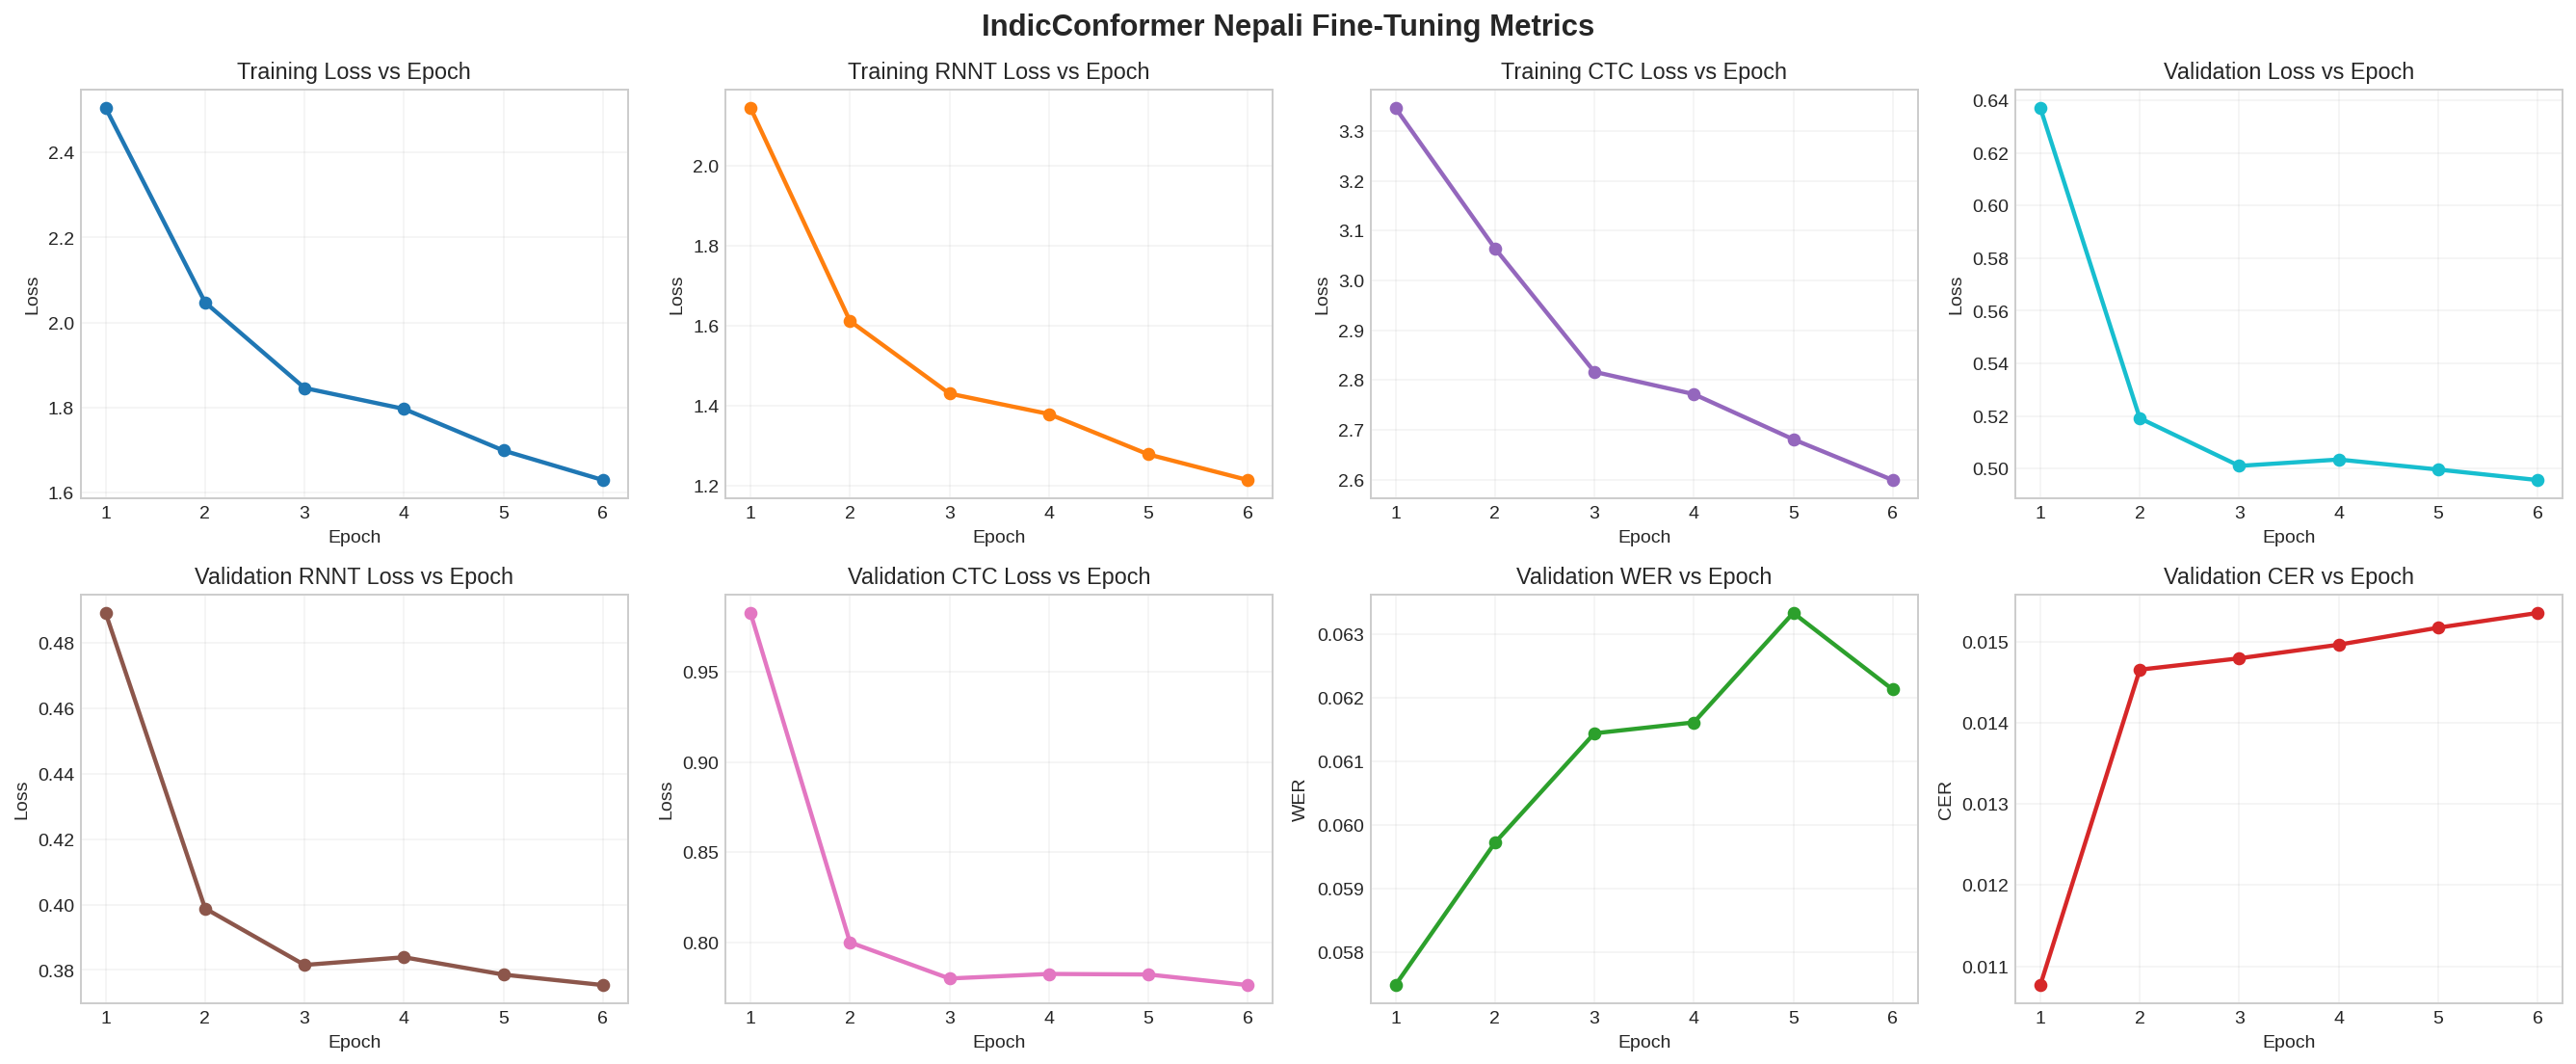

Saved training curves to: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/plots/training_curves.png


In [ ]:
epoch_metrics_path = metrics_dir / "epoch_metrics.csv"
if not epoch_metrics_path.exists():
    raise FileNotFoundError(f"Metric history not found: {epoch_metrics_path}")

history_df = pd.read_csv(epoch_metrics_path).sort_values("epoch").reset_index(drop=True)
display(history_df)

plt.style.use("seaborn-v0_8-whitegrid")
plot_specs = [
    ("train_loss", "Training Loss vs Epoch", "Loss", "#1f77b4"),
    ("train_loss_rnnt", "Training RNNT Loss vs Epoch", "Loss", "#ff7f0e"),
    ("train_loss_ctc", "Training CTC Loss vs Epoch", "Loss", "#9467bd"),
    ("val_loss", "Validation Loss vs Epoch", "Loss", "#17becf"),
    ("val_loss_rnnt", "Validation RNNT Loss vs Epoch", "Loss", "#8c564b"),
    ("val_loss_ctc", "Validation CTC Loss vs Epoch", "Loss", "#e377c2"),
    ("val_wer_eval", "Validation WER vs Epoch", "WER", "#2ca02c"),
    ("val_cer", "Validation CER vs Epoch", "CER", "#d62728"),
]

available_plot_specs = [plot_spec for plot_spec in plot_specs if plot_spec[0] in history_df.columns]
if not available_plot_specs:
    raise ValueError("No known metric columns are available to plot.")

ncols = min(4, len(available_plot_specs))
nrows = (len(available_plot_specs) + ncols - 1) // ncols
figure, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.0 * nrows), dpi=140)
if hasattr(axes, "flatten"):
    axes = axes.flatten()
else:
    axes = [axes]

for axis, (column, title, ylabel, color) in zip(axes, available_plot_specs):
    axis.plot(history_df["epoch"], history_df[column], marker="o", linewidth=2.25, color=color)
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.25)

for axis in axes[len(available_plot_specs):]:
    axis.axis("off")

figure.suptitle("IndicConformer Nepali Fine-Tuning Metrics", fontsize=16, fontweight="bold")
figure.tight_layout()

plot_path = plot_dir / "training_curves.png"
figure.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f"Saved training curves to: {plot_path}")


## Resume and Continue Fine-Tuning

- To continue fine-tuning later from the best model weights, set `cfg.model_init_path` to the exported `best_validation_model.nemo`.
- To resume an interrupted run with optimizer and scheduler state, set `cfg.resume_checkpoint_path` to the saved `last.ckpt`.
- The notebook keeps the original dataset untouched and writes normalized manifests, checkpoints, metrics, predictions, and plots under `cfg.experiment_root / cfg.run_name`.


,epoch,train_loss,train_loss_rnnt,train_loss_ctc,val_loss,val_loss_rnnt,val_loss_ctc,val_wer_eval,val_cer
0,1,2.504485,2.143748,3.346202,0.637098,0.489018,0.982620,0.057484,0.010768
1,2,2.047471,1.611559,3.064597,0.519172,0.398814,0.800010,0.059718,0.014656
2,3,1.846261,1.430399,2.816605,0.501067,0.381539,0.779966,0.061437,0.014796
3,4,1.797101,1.379354,2.771845,0.503480,0.383897,0.782505,0.061609,0.014963
4,5,1.699274,1.278462,2.681168,0.499678,0.378597,0.782199,0.063327,0.015173
5,6,1.629900,1.214391,2.599420,0.495678,0.375401,0.776326,0.062124,0.015355


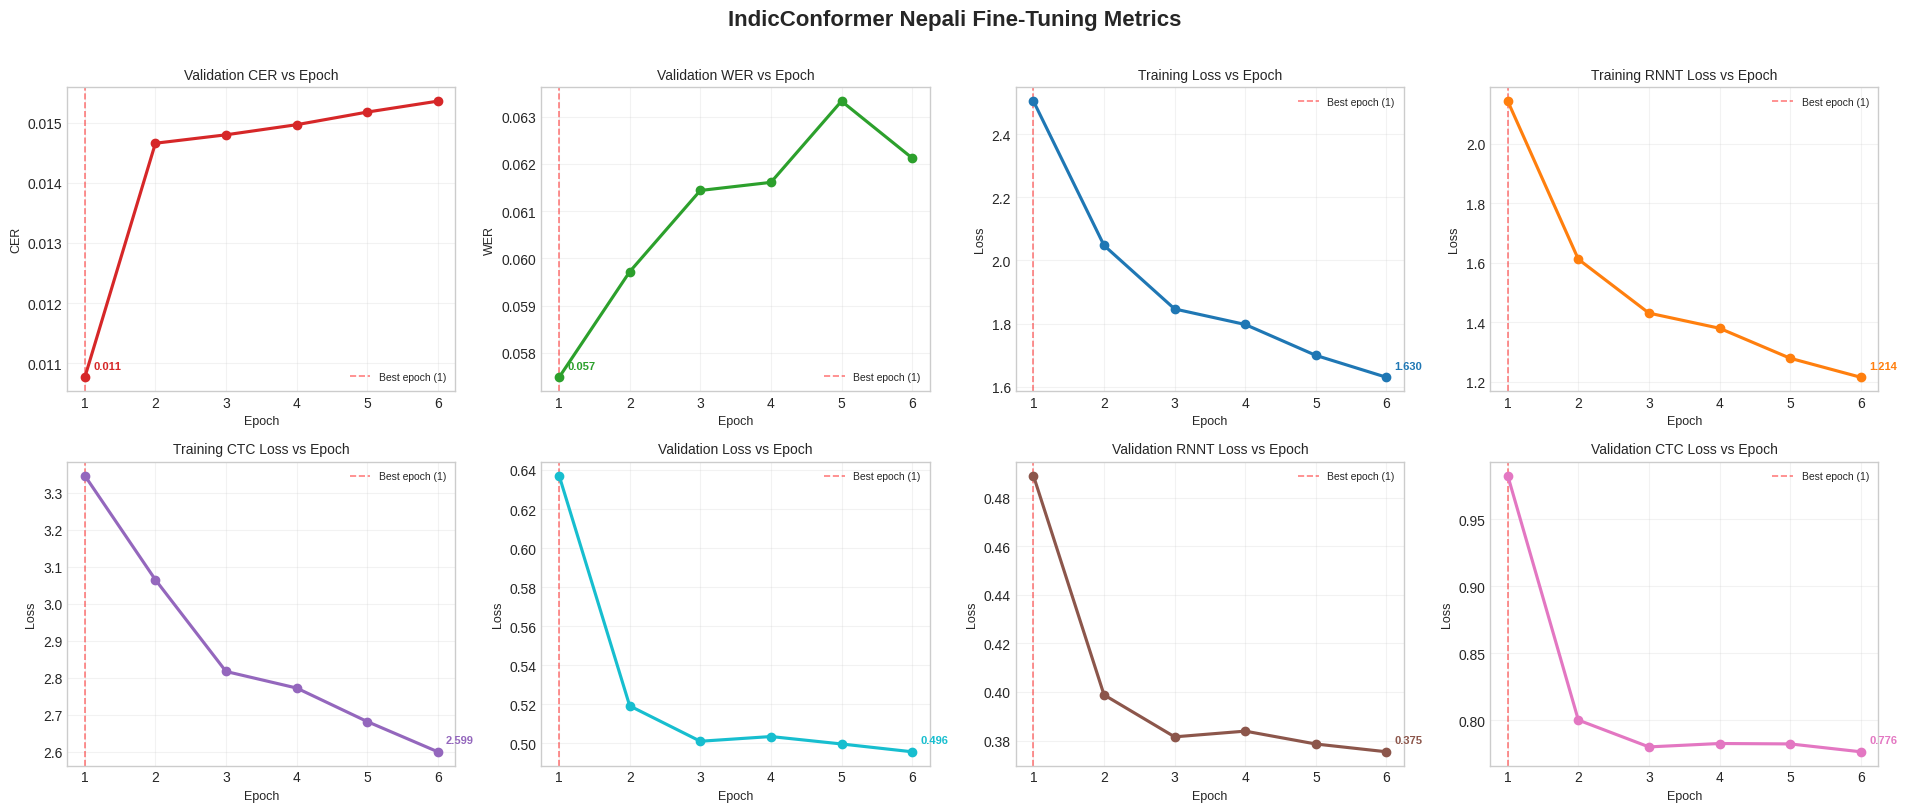

Best epoch (by val_cer): 1
Saved training curves to: /content/drive/MyDrive/nemo_checkpoints/indicconformer_split_manifest/a100_finetune_run/plots/training_curves.png


In [ ]:
epoch_metrics_path = metrics_dir / "epoch_metrics.csv"
if not epoch_metrics_path.exists():
    raise FileNotFoundError(f"Metric history not found: {epoch_metrics_path}")

history_df = pd.read_csv(epoch_metrics_path).sort_values("epoch").reset_index(drop=True)
display(history_df)

plt.style.use("seaborn-v0_8-whitegrid")

plot_specs = [
    ("val_cer",        "Validation CER vs Epoch",        "CER",  "#d62728"),
    ("val_wer_eval",   "Validation WER vs Epoch",        "WER",  "#2ca02c"),
    ("train_loss",     "Training Loss vs Epoch",         "Loss", "#1f77b4"),
    ("train_loss_rnnt","Training RNNT Loss vs Epoch",    "Loss", "#ff7f0e"),
    ("train_loss_ctc", "Training CTC Loss vs Epoch",     "Loss", "#9467bd"),
    ("val_loss",       "Validation Loss vs Epoch",       "Loss", "#17becf"),
    ("val_loss_rnnt",  "Validation RNNT Loss vs Epoch",  "Loss", "#8c564b"),
    ("val_loss_ctc",   "Validation CTC Loss vs Epoch",   "Loss", "#e377c2"),
]

available_plot_specs = [s for s in plot_specs if s[0] in history_df.columns]
if not available_plot_specs:
    raise ValueError("No known metric columns are available to plot.")

# Resolve best epoch from CER if available, else WER, else first available metric
primary_metric = next(
    (col for col in ["val_cer", "val_wer_eval"] if col in history_df.columns),
    available_plot_specs[0][0]
)
best_epoch = history_df.loc[history_df[primary_metric].idxmin(), "epoch"]

ncols = min(4, len(available_plot_specs))
nrows = (len(available_plot_specs) + ncols - 1) // ncols
figure, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.0 * nrows), dpi=100)

axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for axis, (column, title, ylabel, color) in zip(axes, available_plot_specs):
    axis.plot(
        history_df["epoch"], history_df[column],
        marker="o", linewidth=2.25, color=color, zorder=3
    )

    # Best epoch vertical line
    axis.axvline(
        x=best_epoch, color="red", linestyle="--",
        linewidth=1.2, alpha=0.5, label=f"Best epoch ({int(best_epoch)})"
    )

    # Annotate min point for this specific metric
    min_idx   = history_df[column].idxmin()
    min_val   = history_df[column].iloc[min_idx]
    min_epoch = history_df["epoch"].iloc[min_idx]
    axis.annotate(
        f"{min_val:.3f}",
        xy=(min_epoch, min_val),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color=color,
        fontweight="bold"
    )

    axis.set_title(title, fontsize=10)
    axis.set_xlabel("Epoch", fontsize=9)
    axis.set_ylabel(ylabel, fontsize=9)
    axis.grid(True, alpha=0.25)
    axis.legend(fontsize=7.5)
    axis.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # whole epoch numbers only

# Hide unused subplots
for axis in axes[len(available_plot_specs):]:
    axis.axis("off")

figure.suptitle(
    "IndicConformer Nepali Fine-Tuning Metrics",
    fontsize=16, fontweight="bold", y=1.01
)
figure.tight_layout()

plot_path = plot_dir / "training_curves.png"
figure.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f"Best epoch (by {primary_metric}): {int(best_epoch)}")
print(f"Saved training curves to: {plot_path}")